# Import libraries

In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchvision.models import ResNet50_Weights
from nltk.translate.bleu_score import sentence_bleu

# Load data

In [ ]:
from google.colab import files
uploaded = files.upload()  # Chọn file ZIP từ máy tính của bạn


Saving image.zip to image.zip


In [3]:
!unzip -q image.zip -d .
import os
print(os.listdir("image"))

['Image_650.jpg', 'Image_6889.jpg', 'Image_10102.jpg', 'Image_5611.jpg', 'Image_5110.jpg', 'Image_9104.jpg', 'Image_9855.jpg', 'Image_2678.jpg', 'Image_2301.jpg', 'Image_790.jpg', 'Image_11266.jpg', 'Image_1597.jpg', 'Image_2583.jpg', 'Image_7547.jpg', 'Image_7183.jpg', 'Image_4342.jpg', 'Image_3963.jpg', 'Image_2858.jpg', 'Image_12428.jpg', 'Image_742.jpg', 'Image_4854.jpg', 'Image_8857.jpg', 'Image_10788.jpg', 'Image_5031.jpg', 'Image_5269.jpg', 'Image_7720.jpg', 'Image_4961.jpg', 'Image_7602.jpg', 'Image_10896.jpg', 'Image_899.jpg', 'Image_12299.jpg', 'Image_5812.jpg', 'Image_2179.jpg', 'Image_12166.jpg', 'Image_12029.jpg', 'Image_9900.jpg', 'Image_6436.jpg', 'Image_1086.jpg', 'Image_10913.jpg', 'Image_52.jpg', 'Image_1938.jpg', 'Image_121.jpg', 'Image_5161.jpg', 'Image_5490.jpg', 'Image_9594.jpg', 'Image_2096.jpg', 'Image_12.jpg', 'Image_9111.jpg', 'Image_10234.jpg', 'Image_9744.jpg', 'Image_1630.jpg', 'Image_4769.jpg', 'Image_3168.jpg', 'Image_2746.jpg', 'Image_12412.jpg', 'Image_

In [4]:
csv_path = 'QA.csv'
image_folder = 'image'
# Tải file CSV
df = pd.read_csv(csv_path)

# Data Preprocessing

In [7]:
# Định nghĩa thiết bị (GPU nếu có, nếu không thì CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Tiền xử lý ảnh cho tập huấn luyện (giảm mức độ augmentation)
preprocess_train = transforms.Compose([
    transforms.Resize(256),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),  # Giảm mức độ thay đổi
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Tiền xử lý ảnh cho tập validation (không augmentation)
preprocess_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Xây dựng từ điển từ vựng cho câu hỏi và câu trả lời
all_text = df['Question'].tolist() + df['Answer'].tolist()
all_words = ' '.join(all_text).split()
unique_words = set(all_words)
special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
for token in special_tokens:
    unique_words.add(token)
vocab = {word: idx for idx, word in enumerate(unique_words)}
inv_vocab = {idx: word for word, idx in vocab.items()}

# Hàm chuyển văn bản thành chỉ số
def text_to_indices(text, vocab, is_answer=False):
    tokens = text.split()
    if is_answer:
        return [vocab['<start>']] + [vocab.get(word, vocab['<unk>']) for word in tokens] + [vocab['<end>']]
    else:
        return [vocab.get(word, vocab['<unk>']) for word in tokens]

# Áp dụng hàm lên dữ liệu
df['question_indices'] = df['Question'].apply(lambda x: text_to_indices(x, vocab))
df['answer_indices'] = df['Answer'].apply(lambda x: text_to_indices(x, vocab, is_answer=True))

# Tìm độ dài tối đa của câu hỏi và câu trả lời
max_question_len = max(df['question_indices'].apply(len))
max_answer_len = max(df['answer_indices'].apply(len))

#  Dataset and DataLoader

In [8]:
class VQADataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.dataframe = dataframe
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.image_folder, self.dataframe.iloc[idx]['Image'])
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)

        question = torch.tensor(self.dataframe.iloc[idx]['question_indices'], dtype=torch.long)
        answer = torch.tensor(self.dataframe.iloc[idx]['answer_indices'], dtype=torch.long)

        return image, question, answer

# Hàm collate để đệm các chuỗi có độ dài khác nhau
def collate_fn(batch):
    images, questions, answers = zip(*batch)
    questions_padded = torch.nn.utils.rnn.pad_sequence(questions, batch_first=True, padding_value=vocab['<pad>'])
    answers_padded = torch.nn.utils.rnn.pad_sequence(answers, batch_first=True, padding_value=vocab['<pad>'])
    images = torch.stack(images)
    return images, questions_padded, answers_padded

print(f"Số mẫu trong tập: {len(df)}")
# Chia dữ liệu thành train_val và test
train_val_df, test_df = train_test_split(df, test_size=0.01, random_state=42)

# Chia train_val thành train và val
train_df, val_df = train_test_split(train_val_df, test_size=0.2222, random_state=42)  # 0.2222 ~ 20% của tổng dữ liệu

print(f"Số mẫu trong tập train: {len(train_df)}")
print(f"Số mẫu trong tập val: {len(val_df)}")
print(f"Số mẫu trong tập test: {len(test_df)}")

# Tạo dataset và dataloader cho các tập
train_dataset = VQADataset(train_df, image_folder, transform=preprocess_train)
val_dataset = VQADataset(val_df, image_folder, transform=preprocess_val)
test_dataset = VQADataset(test_df, image_folder, transform=preprocess_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

Số mẫu trong tập: 3086
Số mẫu trong tập train: 2376
Số mẫu trong tập val: 679
Số mẫu trong tập test: 31


# Define models

## Pretrain model without attention

In [9]:
# Mô hình không attention (pretrained CNN)
class PretrainedNoAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, image_feature_dim, vocab, inv_vocab, max_answer_len, dropout_rate=0.5):
        super(PretrainedNoAttention, self).__init__()
        self.cnn = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.cnn = nn.Sequential(*list(self.cnn.children())[:-1])

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab['<pad>'])
        self.lstm_question = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

        self.projection_h = nn.Linear(image_feature_dim + hidden_dim, hidden_dim)
        self.projection_c = nn.Linear(image_feature_dim + hidden_dim, hidden_dim)

        self.decoder_lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

        self.dropout = nn.Dropout(dropout_rate)

        self.vocab = vocab
        self.inv_vocab = inv_vocab
        self.max_answer_len = max_answer_len

    def forward(self, images, questions, answers=None, beam_width=3):
        image_features = self.cnn(images).view(images.size(0), -1)

        question_embed = self.embedding(questions)
        _, (question_hidden, _) = self.lstm_question(question_embed)
        question_hidden = question_hidden.squeeze(0)

        combined = torch.cat([image_features, question_hidden], dim=1)
        initial_h = self.projection_h(combined).unsqueeze(0)
        initial_c = self.projection_c(combined).unsqueeze(0)

        if answers is not None:
            answer_embed = self.embedding(answers[:, :-1])
            decoder_output, _ = self.decoder_lstm(answer_embed, (initial_h, initial_c))
            decoder_output = self.dropout(decoder_output)
            logits = self.output_layer(decoder_output)
            return logits
        else:
            batch_size = images.size(0)
            beams = [ [(0, [self.vocab['<start>']], (initial_h[:, i:i+1], initial_c[:, i:i+1]))] for i in range(batch_size) ]
            completed_beams = [ [] for _ in range(batch_size) ]

            for _ in range(self.max_answer_len):
              all_candidates = [ [] for _ in range(batch_size) ]
              for i in range(batch_size):
                  for score, sequence, hidden in beams[i]:
                      if sequence[-1] == self.vocab['<end>']:
                          completed_beams[i].append((score, sequence))
                          continue
                      current_word = torch.tensor([[sequence[-1]]], dtype=torch.long).to(device)
                      word_embed = self.embedding(current_word)
                      decoder_output, new_hidden = self.decoder_lstm(word_embed, hidden)
                      logits = self.output_layer(decoder_output.squeeze(1))
                      log_probs = torch.log_softmax(logits, dim=-1)  # Chuyển logits thành log probability
                      top_k = torch.topk(log_probs, beam_width, dim=-1)
                      for k in range(beam_width):
                          new_score = score + top_k.values[0, k].item()
                          new_word = top_k.indices[0, k].item()
                          new_sequence = sequence + [new_word]
                          all_candidates[i].append((new_score, new_sequence, new_hidden))

              for i in range(batch_size):
                  beams[i] = sorted(all_candidates[i], key=lambda x: x[0], reverse=True)[:beam_width]

            # Chọn beam tốt nhất cho mỗi mẫu trong batch
            predicted_answers = []
            for i in range(batch_size):
                if completed_beams[i]:
                    best_beam = max(completed_beams[i], key=lambda x: x[0])
                else:
                    best_beam = max(beams[i], key=lambda x: x[0])
                predicted_indices = best_beam[1][1:]
                answer = ' '.join([self.inv_vocab[idx] for idx in predicted_indices if idx != self.vocab['<end>']])
                predicted_answers.append(answer)
            return predicted_answers

## Pretrain model with attention

In [12]:
class PretrainedWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, image_feature_dim, vocab, inv_vocab, max_answer_len, dropout_rate=0.7):
      super(PretrainedWithAttention, self).__init__()
      self.cnn = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)  # Đảm bảo models là torchvision.models
      self.cnn = nn.Sequential(*list(self.cnn.children())[:-2])
      self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab['<pad>'])
      self.lstm_question = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

      self.attention = nn.Linear(hidden_dim + 2048, 1)
      self.decoder_lstm = nn.LSTM(embedding_dim + 2048, hidden_dim, batch_first=True)
      self.output_layer = nn.Linear(hidden_dim, vocab_size)

      self.dropout = nn.Dropout(dropout_rate)

      self.vocab = vocab
      self.inv_vocab = inv_vocab
      self.max_answer_len = max_answer_len

    def forward(self, images, questions, answers=None, beam_width=3):
          image_features = self.cnn(images)
          image_features_flat = image_features.view(images.size(0), 2048, -1).permute(0, 2, 1)

          question_embed = self.embedding(questions)
          _, (question_hidden, _) = self.lstm_question(question_embed)
          question_hidden = question_hidden.squeeze(0)

          if answers is not None:
              # Chế độ huấn luyện
              decoder_hidden = question_hidden.unsqueeze(0)
              decoder_cell = torch.zeros_like(decoder_hidden)
              answer_embed = self.embedding(answers[:, :-1])
              outputs = []
              for t in range(answer_embed.size(1)):
                  attn_input = torch.cat([decoder_hidden.repeat(image_features_flat.size(1), 1, 1).permute(1, 0, 2),
                                          image_features_flat], dim=-1)
                  attn_weights = torch.softmax(self.attention(attn_input), dim=1)
                  context = (attn_weights * image_features_flat).sum(dim=1)
                  decoder_input = torch.cat([answer_embed[:, t, :], context], dim=-1).unsqueeze(1)
                  decoder_output, (decoder_hidden, decoder_cell) = self.decoder_lstm(decoder_input, (decoder_hidden, decoder_cell))
                  decoder_output = self.dropout(decoder_output)
                  outputs.append(self.output_layer(decoder_output.squeeze(1)))
              outputs = torch.stack(outputs, dim=1)
              return outputs
          else:
              # Chế độ suy luận với beam search
              batch_size = images.size(0)
              beams = [[(0, [self.vocab['<start>']], (question_hidden[i:i+1].unsqueeze(0), torch.zeros_like(question_hidden[i:i+1].unsqueeze(0))))] for i in range(batch_size)]
              completed_beams = [[] for _ in range(batch_size)]

              for _ in range(self.max_answer_len):
                  all_candidates = [[] for _ in range(batch_size)]
                  for i in range(batch_size):
                      for score, sequence, (hidden, cell) in beams[i]:
                          if sequence[-1] == self.vocab['<end>']:
                              completed_beams[i].append((score, sequence))
                              continue
                          current_word = torch.tensor([[sequence[-1]]], dtype=torch.long).to(device)
                          word_embed = self.embedding(current_word).squeeze(1)
                          attn_input = torch.cat([hidden.repeat(image_features_flat.size(1), 1, 1).permute(1, 0, 2),
                                                  image_features_flat[i:i+1]], dim=-1)
                          attn_weights = torch.softmax(self.attention(attn_input), dim=1)
                          context = (attn_weights * image_features_flat[i:i+1]).sum(dim=1)
                          decoder_input = torch.cat([word_embed, context], dim=-1).unsqueeze(1)
                          decoder_output, (new_hidden, new_cell) = self.decoder_lstm(decoder_input, (hidden, cell))
                          logits = self.output_layer(decoder_output.squeeze(1))
                          log_probs = torch.log_softmax(logits, dim=-1)
                          top_k = torch.topk(log_probs, beam_width, dim=-1)
                          for k in range(beam_width):
                              new_score = score + top_k.values[0, k].item()
                              new_word = top_k.indices[0, k].item()
                              new_sequence = sequence + [new_word]
                              all_candidates[i].append((new_score, new_sequence, (new_hidden, new_cell)))

                  for i in range(batch_size):
                      beams[i] = sorted(all_candidates[i], key=lambda x: x[0], reverse=True)[:beam_width]

              predicted_answers = []
              for i in range(batch_size):
                  if completed_beams[i]:
                      best_beam = max(completed_beams[i], key=lambda x: x[0])
                  else:
                      best_beam = max(beams[i], key=lambda x: x[0])
                  predicted_indices = best_beam[1][1:]
                  answer = ' '.join([self.inv_vocab[idx] for idx in predicted_indices if idx != self.vocab['<end>']])
                  predicted_answers.append(answer)
              return predicted_answers

## Train model without attention

In [13]:
# Mô hình không attention (trained CNN)
class TrainedNoAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, image_feature_dim, vocab, inv_vocab, max_answer_len, dropout_rate=0.5):
        super(TrainedNoAttention, self).__init__()
        self.cnn = models.resnet50(weights=None)
        self.cnn = nn.Sequential(*list(self.cnn.children())[:-1])

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab['<pad>'])
        self.lstm_question = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

        self.projection_h = nn.Linear(image_feature_dim + hidden_dim, hidden_dim)
        self.projection_c = nn.Linear(image_feature_dim + hidden_dim, hidden_dim)

        self.decoder_lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

        self.dropout = nn.Dropout(dropout_rate)

        self.vocab = vocab
        self.inv_vocab = inv_vocab
        self.max_answer_len = max_answer_len

    def forward(self, images, questions, answers=None, beam_width=3):
        image_features = self.cnn(images).view(images.size(0), -1)

        question_embed = self.embedding(questions)
        _, (question_hidden, _) = self.lstm_question(question_embed)
        question_hidden = question_hidden.squeeze(0)

        combined = torch.cat([image_features, question_hidden], dim=1)
        initial_h = self.projection_h(combined).unsqueeze(0)
        initial_c = self.projection_c(combined).unsqueeze(0)

        if answers is not None:
            answer_embed = self.embedding(answers[:, :-1])
            decoder_output, _ = self.decoder_lstm(answer_embed, (initial_h, initial_c))
            decoder_output = self.dropout(decoder_output)
            logits = self.output_layer(decoder_output)
            return logits
        else:
            batch_size = images.size(0)
            beams = [[(0, [self.vocab['<start>']], (initial_h[:, i:i+1], initial_c[:, i:i+1]))] for i in range(batch_size)]
            completed_beams = [[] for _ in range(batch_size)]

            for _ in range(self.max_answer_len):
                all_candidates = [[] for _ in range(batch_size)]
                for i in range(batch_size):
                    for score, sequence, hidden in beams[i]:
                        if sequence[-1] == self.vocab['<end>']:
                            completed_beams[i].append((score, sequence))
                            continue
                        current_word = torch.tensor([[sequence[-1]]], dtype=torch.long).to(device)
                        word_embed = self.embedding(current_word)
                        decoder_output, new_hidden = self.decoder_lstm(word_embed, hidden)
                        logits = self.output_layer(decoder_output.squeeze(1))
                        log_probs = torch.log_softmax(logits, dim=-1)  # Thêm Log Softmax
                        top_k = torch.topk(log_probs, beam_width, dim=-1)
                        for k in range(beam_width):
                            new_score = score + top_k.values[0, k].item()
                            new_word = top_k.indices[0, k].item()
                            new_sequence = sequence + [new_word]
                            all_candidates[i].append((new_score, new_sequence, new_hidden))

                for i in range(batch_size):
                    beams[i] = sorted(all_candidates[i], key=lambda x: x[0], reverse=True)[:beam_width]

            predicted_answers = []
            for i in range(batch_size):
                if completed_beams[i]:
                    best_beam = max(completed_beams[i], key=lambda x: x[0])
                else:
                    best_beam = max(beams[i], key=lambda x: x[0])
                predicted_indices = best_beam[1][1:]
                answer = ' '.join([self.inv_vocab[idx] for idx in predicted_indices if idx != self.vocab['<end>']])
                predicted_answers.append(answer)
            return predicted_answers

## Train model with attention

In [14]:
class TrainedWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, image_feature_dim, vocab, inv_vocab, max_answer_len, dropout_rate=0.7):
        super(TrainedWithAttention, self).__init__()
        self.cnn = models.resnet50(weights=None)  # Đảm bảo models là torchvision.models
        self.cnn = nn.Sequential(*list(self.cnn.children())[:-2])
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab['<pad>'])
        self.lstm_question = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

        self.attention = nn.Linear(hidden_dim + 2048, 1)
        self.decoder_lstm = nn.LSTM(embedding_dim + 2048, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

        self.dropout = nn.Dropout(dropout_rate)

        self.vocab = vocab
        self.inv_vocab = inv_vocab
        self.max_answer_len = max_answer_len

    def forward(self, images, questions, answers=None, beam_width=3):
        image_features = self.cnn(images)
        image_features_flat = image_features.view(images.size(0), 2048, -1).permute(0, 2, 1)

        question_embed = self.embedding(questions)
        _, (question_hidden, _) = self.lstm_question(question_embed)
        question_hidden = question_hidden.squeeze(0)

        if answers is not None:
            # Chế độ huấn luyện
            decoder_hidden = question_hidden.unsqueeze(0)
            decoder_cell = torch.zeros_like(decoder_hidden)
            answer_embed = self.embedding(answers[:, :-1])
            outputs = []
            for t in range(answer_embed.size(1)):
                attn_input = torch.cat([decoder_hidden.repeat(image_features_flat.size(1), 1, 1).permute(1, 0, 2),
                                        image_features_flat], dim=-1)
                attn_weights = torch.softmax(self.attention(attn_input), dim=1)
                context = (attn_weights * image_features_flat).sum(dim=1)
                decoder_input = torch.cat([answer_embed[:, t, :], context], dim=-1).unsqueeze(1)
                decoder_output, (decoder_hidden, decoder_cell) = self.decoder_lstm(decoder_input, (decoder_hidden, decoder_cell))
                decoder_output = self.dropout(decoder_output)
                outputs.append(self.output_layer(decoder_output.squeeze(1)))
            outputs = torch.stack(outputs, dim=1)
            return outputs
        else:
            # Chế độ suy luận với beam search
            batch_size = images.size(0)
            beams = [[(0, [self.vocab['<start>']], (question_hidden[i:i+1].unsqueeze(0), torch.zeros_like(question_hidden[i:i+1].unsqueeze(0))))] for i in range(batch_size)]
            completed_beams = [[] for _ in range(batch_size)]

            for _ in range(self.max_answer_len):
                all_candidates = [[] for _ in range(batch_size)]
                for i in range(batch_size):
                    for score, sequence, (hidden, cell) in beams[i]:
                        if sequence[-1] == self.vocab['<end>']:
                            completed_beams[i].append((score, sequence))
                            continue
                        current_word = torch.tensor([[sequence[-1]]], dtype=torch.long).to(device)
                        word_embed = self.embedding(current_word).squeeze(1)
                        attn_input = torch.cat([hidden.repeat(image_features_flat.size(1), 1, 1).permute(1, 0, 2),
                                                image_features_flat[i:i+1]], dim=-1)
                        attn_weights = torch.softmax(self.attention(attn_input), dim=1)
                        context = (attn_weights * image_features_flat[i:i+1]).sum(dim=1)
                        decoder_input = torch.cat([word_embed, context], dim=-1).unsqueeze(1)
                        decoder_output, (new_hidden, new_cell) = self.decoder_lstm(decoder_input, (hidden, cell))
                        logits = self.output_layer(decoder_output.squeeze(1))
                        log_probs = torch.log_softmax(logits, dim=-1)
                        top_k = torch.topk(log_probs, beam_width, dim=-1)
                        for k in range(beam_width):
                            new_score = score + top_k.values[0, k].item()
                            new_word = top_k.indices[0, k].item()
                            new_sequence = sequence + [new_word]
                            all_candidates[i].append((new_score, new_sequence, (new_hidden, new_cell)))

                for i in range(batch_size):
                    beams[i] = sorted(all_candidates[i], key=lambda x: x[0], reverse=True)[:beam_width]

            predicted_answers = []
            for i in range(batch_size):
                if completed_beams[i]:
                    best_beam = max(completed_beams[i], key=lambda x: x[0])
                else:
                    best_beam = max(beams[i], key=lambda x: x[0])
                predicted_indices = best_beam[1][1:]
                answer = ' '.join([self.inv_vocab[idx] for idx in predicted_indices if idx != self.vocab['<end>']])
                predicted_answers.append(answer)
            return predicted_answers

# Define early stopping,bleu score and trainning loop

In [15]:
# Class Early Stopping
class EarlyStopping:
    def __init__(self, patience=3, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.best_model_state = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict()
        elif val_loss > self.best_loss + self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict()
            self.counter = 0

In [16]:
def evaluate_bleu(model, test_loader, inv_vocab, vocab):
    model.eval()
    bleu_scores = []
    with torch.no_grad():
        for images, questions, answers in test_loader:
            images, questions, answers = images.to(device), questions.to(device), answers.to(device)
            # Dự đoán câu trả lời
            predicted_answers = []
            for i in range(images.size(0)):  # Dự đoán từng mẫu trong batch
                pred_answer = model(images[i:i+1], questions[i:i+1])  # Gọi forward với batch size 1
                predicted_answers.append(pred_answer.split())  # Chia thành danh sách từ

            # Chuẩn bị câu trả lời thực tế
            for pred, ref in zip(predicted_answers, answers):
                ref_text = ' '.join([inv_vocab[idx.item()] for idx in ref if idx.item() not in [vocab['<pad>'], vocab['<start>'], vocab['<end>']]])
                bleu = sentence_bleu([ref_text.split()], pred)  # Tính Bleu score
                bleu_scores.append(bleu)

    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0
    print(f"Average Bleu Score on Test Set: {avg_bleu:.4f}")
    return avg_bleu

In [17]:
# Hàm huấn luyện chung
def train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer, early_stopping):
    train_losses = []
    val_losses = []
    accuracies = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for images, questions, answers in train_loader:
            images, questions, answers = images.to(device), questions.to(device), answers.to(device)
            optimizer.zero_grad()
            logits = model(images, questions, answers)
            loss = criterion(logits.view(-1, len(vocab)), answers[:, 1:].contiguous().view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, questions, answers in val_loader:
                images, questions, answers = images.to(device), questions.to(device), answers.to(device)
                logits = model(images, questions, answers)
                val_loss += criterion(logits.view(-1, len(vocab)), answers[:, 1:].contiguous().view(-1)).item()

                _, predicted = logits.max(-1)
                predicted = predicted.view(-1)
                answers_flat = answers[:, 1:].contiguous().view(-1)
                mask = answers_flat != vocab['<pad>']
                correct += (predicted[mask] == answers_flat[mask]).sum().item()
                total += mask.sum().item()
        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)
        accuracy = correct / total if total > 0 else 0
        accuracies.append(accuracy)

        print(f"Epoch {epoch+1}, Train Loss: {train_loss}, Validation Loss: {val_loss}, Accuracy: {accuracy}")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Stopped training early!")
            model.load_state_dict(early_stopping.best_model_state)
            break

    return train_losses, val_losses, accuracies

# Initialize and train 4 models

In [18]:
vocab_size = len(vocab)
image_feature_dim = 2048  # for ResNet50

# 1. PretrainedNoAttention
pretrained_no_attention = PretrainedNoAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)
optimizer_pna = torch.optim.Adam(pretrained_no_attention.parameters(), lr=0.001, weight_decay=1e-4)
early_stopping_pna = EarlyStopping(patience=5)
train_losses_pna, val_losses_pna, accuracies_pna = train_model(
    pretrained_no_attention, train_loader, val_loader, num_epochs=40,
    criterion=nn.CrossEntropyLoss(ignore_index=vocab['<pad>']), optimizer=optimizer_pna, early_stopping=early_stopping_pna
)
torch.save(pretrained_no_attention.state_dict(), 'pretrained_no_attention.pth')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


Epoch 1, Train Loss: 3.691015230814616, Validation Loss: 2.587601759217002, Accuracy: 0.46605573218627266
Epoch 2, Train Loss: 2.388108731905619, Validation Loss: 2.1936850493604485, Accuracy: 0.5008415934168693
Epoch 3, Train Loss: 2.044077280362447, Validation Loss: 1.9860074465925044, Accuracy: 0.5287076865532074
Epoch 4, Train Loss: 1.8232680320739747, Validation Loss: 1.8790084015239368, Accuracy: 0.5561997381709369
Epoch 5, Train Loss: 1.6898441235224406, Validation Loss: 1.8034056208350442, Accuracy: 0.5707873573966711
Epoch 6, Train Loss: 1.5813827339808146, Validation Loss: 1.7489967671307651, Accuracy: 0.5818215821956237
Epoch 7, Train Loss: 1.4918345069885255, Validation Loss: 1.700554538856853, Accuracy: 0.5917336824387507
Epoch 8, Train Loss: 1.3913098430633546, Validation Loss: 1.64606234702197, Accuracy: 0.6119319244436132
Epoch 9, Train Loss: 1.2993555402755737, Validation Loss: 1.5913752534172751, Accuracy: 0.6353095193566486
Epoch 10, Train Loss: 1.2302369960149129, V

In [19]:
# 2. PretrainedWithAttention
pretrained_with_attention = PretrainedWithAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)
optimizer_pwa = torch.optim.Adam(pretrained_with_attention.parameters(), lr=0.001, weight_decay=1e-4)
early_stopping_pwa = EarlyStopping(patience=5)
train_losses_pwa, val_losses_pwa, accuracies_pwa = train_model(
    pretrained_with_attention, train_loader, val_loader, num_epochs=40,
    criterion=nn.CrossEntropyLoss(ignore_index=vocab['<pad>']), optimizer=optimizer_pwa, early_stopping=early_stopping_pwa
)
torch.save(pretrained_with_attention.state_dict(), 'pretrained_with_attention.pth')

Epoch 1, Train Loss: 4.167722635269165, Validation Loss: 2.8139901052821767, Accuracy: 0.4286515803254161
Epoch 2, Train Loss: 2.572737553914388, Validation Loss: 2.2044820839708503, Accuracy: 0.5328221432579017
Epoch 3, Train Loss: 2.136601071357727, Validation Loss: 1.9792712276632136, Accuracy: 0.5633065270244997
Epoch 4, Train Loss: 1.9046001291275025, Validation Loss: 1.8569233200766824, Accuracy: 0.5924817654759679
Epoch 5, Train Loss: 1.7603794495264689, Validation Loss: 1.786344739523801, Accuracy: 0.5980923882550964
Epoch 6, Train Loss: 1.6483999268213907, Validation Loss: 1.7561256668784402, Accuracy: 0.5994015335702263
Epoch 7, Train Loss: 1.5681809997558593, Validation Loss: 1.679567727175626, Accuracy: 0.6124929867215261
Epoch 8, Train Loss: 1.491586922009786, Validation Loss: 1.6550486141985112, Accuracy: 0.6121189452029175
Epoch 9, Train Loss: 1.4311941973368327, Validation Loss: 1.623145732012662, Accuracy: 0.6274546474658688
Epoch 10, Train Loss: 1.3808820374806723, Va

In [20]:
# 3. TrainedNoAttention
trained_no_attention = TrainedNoAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)
optimizer_tna = torch.optim.Adam(trained_no_attention.parameters(), lr=0.001, weight_decay=1e-4)
early_stopping_tna = EarlyStopping(patience=5)
train_losses_tna, val_losses_tna, accuracies_tna = train_model(
    trained_no_attention, train_loader, val_loader, num_epochs=40,
    criterion=nn.CrossEntropyLoss(ignore_index=vocab['<pad>']), optimizer=optimizer_tna, early_stopping=early_stopping_tna
)
torch.save(trained_no_attention.state_dict(), 'trained_no_attention.pth')

Epoch 1, Train Loss: 3.727134936650594, Validation Loss: 2.6518267176368018, Accuracy: 0.4322049747521975
Epoch 2, Train Loss: 2.4216827821731566, Validation Loss: 2.224224079738964, Accuracy: 0.48550589115391807
Epoch 3, Train Loss: 2.0979922835032143, Validation Loss: 2.064106664874337, Accuracy: 0.5072002992332149
Epoch 4, Train Loss: 1.8800194946924846, Validation Loss: 2.0427428592335093, Accuracy: 0.515242191883299
Epoch 5, Train Loss: 1.7445433378219604, Validation Loss: 1.8506837378848682, Accuracy: 0.5588180288011969
Epoch 6, Train Loss: 1.630745660463969, Validation Loss: 1.8884295496073635, Accuracy: 0.5358144754067702
EarlyStopping counter: 1/5
Epoch 7, Train Loss: 1.5529727347691853, Validation Loss: 1.7581265785477378, Accuracy: 0.5749018141013652
Epoch 8, Train Loss: 1.4797807391484579, Validation Loss: 1.7479085651311008, Accuracy: 0.5651767346175426
Epoch 9, Train Loss: 1.426654076576233, Validation Loss: 1.7203464778986843, Accuracy: 0.5874322049747522
Epoch 10, Train

In [21]:
# 4. TrainedWithAttention
trained_with_attention = TrainedWithAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)
optimizer_twa = torch.optim.Adam(trained_with_attention.parameters(), lr=0.001, weight_decay=1e-4)
early_stopping_twa = EarlyStopping(patience=5)
train_losses_twa, val_losses_twa, accuracies_twa = train_model(
    trained_with_attention, train_loader, val_loader, num_epochs=40,
    criterion=nn.CrossEntropyLoss(ignore_index=vocab['<pad>']), optimizer=optimizer_twa, early_stopping=early_stopping_twa
)
torch.save(trained_with_attention.state_dict(), 'trained_with_attention.pth')

Epoch 1, Train Loss: 4.3267845471700035, Validation Loss: 3.5513499433344062, Accuracy: 0.3388816158593604
Epoch 2, Train Loss: 2.66804682413737, Validation Loss: 2.3096841953017493, Accuracy: 0.49130353469235083
Epoch 3, Train Loss: 2.2108892520268757, Validation Loss: 1.9990476424043828, Accuracy: 0.5670469422105854
Epoch 4, Train Loss: 1.9404907703399659, Validation Loss: 1.8614405014298179, Accuracy: 0.5848139143444923
Epoch 5, Train Loss: 1.7731413571039836, Validation Loss: 1.7728277011351152, Accuracy: 0.5962221806620535
Epoch 6, Train Loss: 1.6630656814575195, Validation Loss: 1.704712065783414, Accuracy: 0.6222180662053488
Epoch 7, Train Loss: 1.5519422276814778, Validation Loss: 1.6517841003157876, Accuracy: 0.630259958855433
Epoch 8, Train Loss: 1.4638108777999879, Validation Loss: 1.6077321280132642, Accuracy: 0.6319431456891715
Epoch 9, Train Loss: 1.4084356578191122, Validation Loss: 1.5757664225318215, Accuracy: 0.6384888722648214
Epoch 10, Train Loss: 1.3383365519841512

# Diagram for comparision

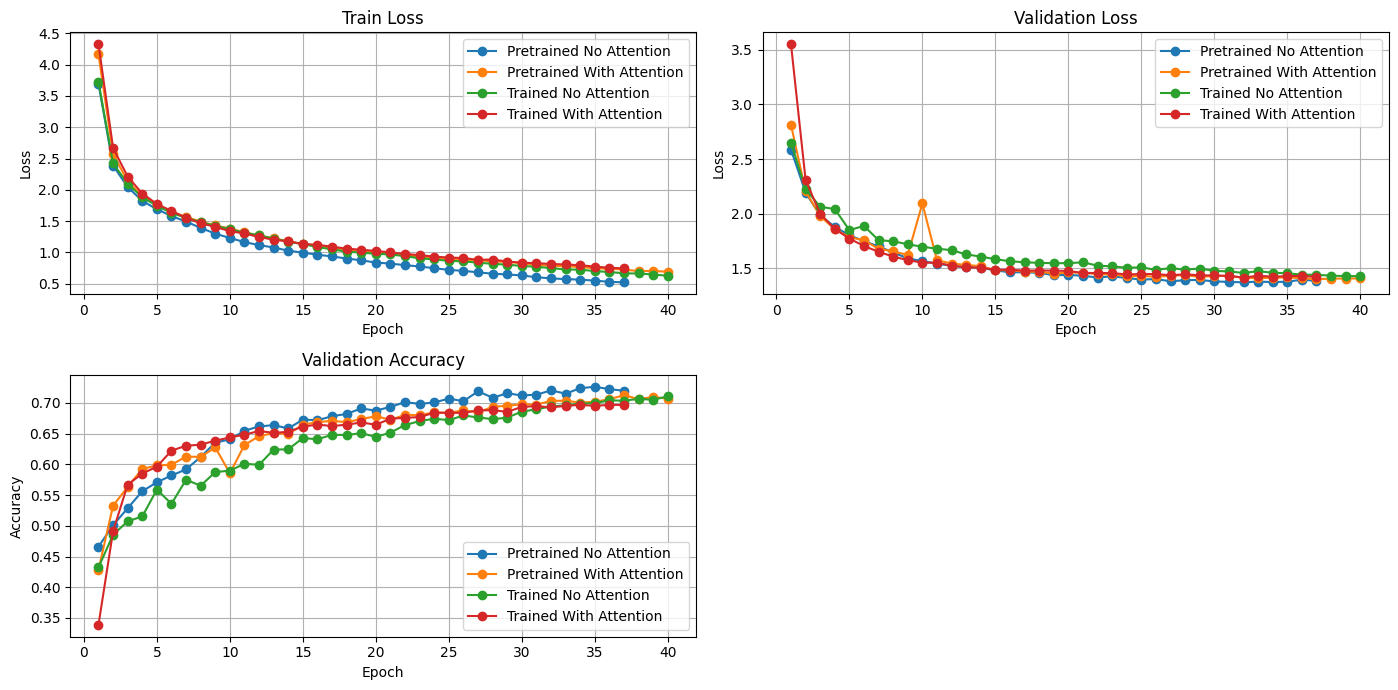

In [23]:
# plot Train Loss, Val Loss and  Accuracy diagrams for 4 models
plt.figure(figsize=(14, 7))

# Train Loss
plt.subplot(2, 2, 1)
plt.plot(range(1, len(train_losses_pna) + 1), train_losses_pna, label='Pretrained No Attention', marker='o')
plt.plot(range(1, len(train_losses_pwa) + 1), train_losses_pwa, label='Pretrained With Attention', marker='o')
plt.plot(range(1, len(train_losses_tna) + 1), train_losses_tna, label='Trained No Attention', marker='o')
plt.plot(range(1, len(train_losses_twa) + 1), train_losses_twa, label='Trained With Attention', marker='o')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Validation Loss
plt.subplot(2, 2, 2)
plt.plot(range(1, len(val_losses_pna) + 1), val_losses_pna, label='Pretrained No Attention', marker='o')
plt.plot(range(1, len(val_losses_pwa) + 1), val_losses_pwa, label='Pretrained With Attention', marker='o')
plt.plot(range(1, len(val_losses_tna) + 1), val_losses_tna, label='Trained No Attention', marker='o')
plt.plot(range(1, len(val_losses_twa) + 1), val_losses_twa, label='Trained With Attention', marker='o')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Accuracy
plt.subplot(2, 2, 3)
plt.plot(range(1, len(accuracies_pna) + 1), accuracies_pna, label='Pretrained No Attention', marker='o')
plt.plot(range(1, len(accuracies_pwa) + 1), accuracies_pwa, label='Pretrained With Attention', marker='o')
plt.plot(range(1, len(accuracies_tna) + 1), accuracies_tna, label='Trained No Attention', marker='o')
plt.plot(range(1, len(accuracies_twa) + 1), accuracies_twa, label='Trained With Attention', marker='o')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()




# Load Weight of models

In [ ]:
# Khởi tạo lại mô hình
pretrained_no_attention = PretrainedNoAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)

pretrained_with_attention = PretrainedWithAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)

trained_no_attention = TrainedNoAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)

trained_with_attention = TrainedWithAttention(
    vocab_size, embedding_dim=300, hidden_dim=512, image_feature_dim=image_feature_dim,
    vocab=vocab, inv_vocab=inv_vocab, max_answer_len=max_answer_len
).to(device)

# Tải trọng số vào mô hình mới khởi tạo
pretrained_with_attention.load_state_dict(torch.load('pretrained_with_attention.pth'))
trained_with_attention.load_state_dict(torch.load('trained_with_attention.pth'))
pretrained_no_attention.load_state_dict(torch.load('pretrained_no_attention.pth'))
trained_no_attention.load_state_dict(torch.load('trained_no_attention.pth'))

<All keys matched successfully>

# Testing

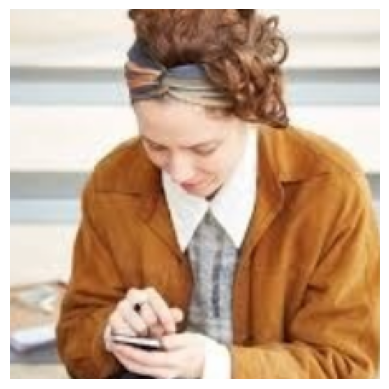

Sample quetion: How does the woman feel while texting?
The practical answer: She feels thoughtful and attentive.
Câu trả lời dự đoán Pretrained No Attention: ['She feels calm and content.']
Câu trả lời dự đoán Pretrained With Attention: ['She feels relaxed and content.']
Câu trả lời dự đoán Trained No Attention: ['She feels happy and relaxed.']
Câu trả lời dự đoán Trained With attention: ['She feels calm and content.']
Press 'Enter' to continue or enter 'stop' to stop: 


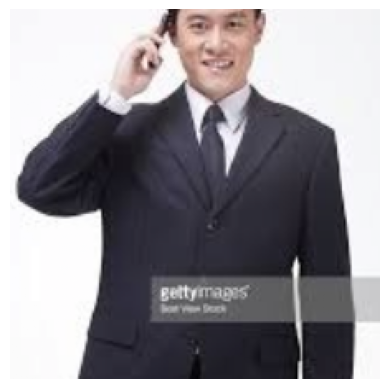

Sample quetion: How does his smile show his mood?
The practical answer: His smile shows he feels happy and confident.
Câu trả lời dự đoán Pretrained No Attention: ['His smile shows he feels happy and relaxed.']
Câu trả lời dự đoán Pretrained With Attention: ['His smile shows he feels happy and relaxed.']
Câu trả lời dự đoán Trained No Attention: ['His smile shows he feels happy and relaxed.']
Câu trả lời dự đoán Trained With attention: ['His smile shows he feels happy and relaxed.']
Press 'Enter' to continue or enter 'stop' to stop: 


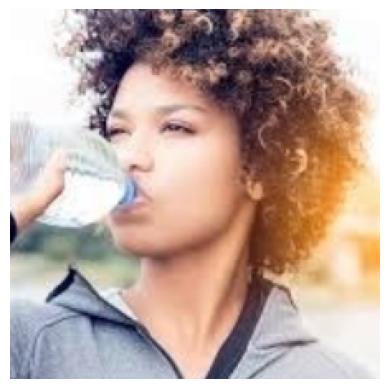

Sample quetion: Is she hydrating with her water bottle?
The practical answer: Yes, she’s hydrating with her water bottle.
Câu trả lời dự đoán Pretrained No Attention: ['Yes, she’s sipping a healthy drink with her bottle.']
Câu trả lời dự đoán Pretrained With Attention: ['Yes, she’s coordinating a project with her phone and laptop.']
Câu trả lời dự đoán Trained No Attention: ['Yes, she’s catching up with someone during her drive.']
Câu trả lời dự đoán Trained With attention: ['Yes, she’s catching up with someone on her phone.']
Press 'Enter' to continue or enter 'stop' to stop: 


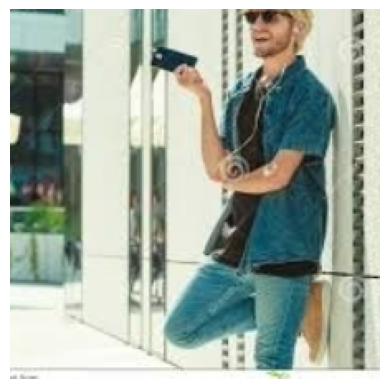

Sample quetion: How strongly does he convey happiness?
The practical answer: He conveys happiness brightly.
Câu trả lời dự đoán Pretrained No Attention: ['He conveys happiness brightly.']
Câu trả lời dự đoán Pretrained With Attention: ['He reflects happiness brightly.']
Câu trả lời dự đoán Trained No Attention: ['He conveys happiness brightly.']
Câu trả lời dự đoán Trained With attention: ['He conveys focus intently.']
Press 'Enter' to continue or enter 'stop' to stop: 


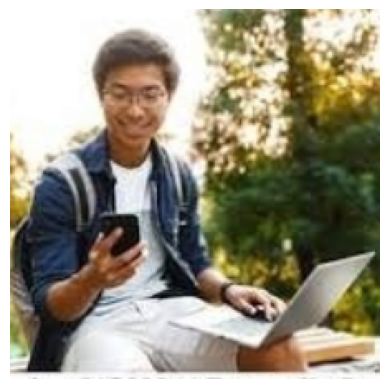

Sample quetion: Is the man feeling attentive while multitasking?
The practical answer: Yes, the man is feeling attentive.
Câu trả lời dự đoán Pretrained No Attention: ['Yes, the man is feeling relaxed.']
Câu trả lời dự đoán Pretrained With Attention: ['Yes, the man is feeling relaxed.']
Câu trả lời dự đoán Trained No Attention: ['Yes, the man is feeling relaxed.']
Câu trả lời dự đoán Trained With attention: ['Yes, the man is feeling relaxed.']
Press 'Enter' to continue or enter 'stop' to stop: 


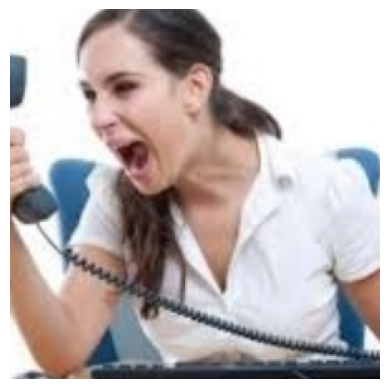

Sample quetion: What activity is the woman engaged in with the phone?
The practical answer: The woman is talking on the phone at her desk.
Câu trả lời dự đoán Pretrained No Attention: ['The woman is talking on the phone.']
Câu trả lời dự đoán Pretrained With Attention: ['The woman is talking on the phone.']
Câu trả lời dự đoán Trained No Attention: ['The woman is talking on the phone.']
Câu trả lời dự đoán Trained With attention: ['The woman is talking on the phone while holding a laptop.']
Press 'Enter' to continue or enter 'stop' to stop: 


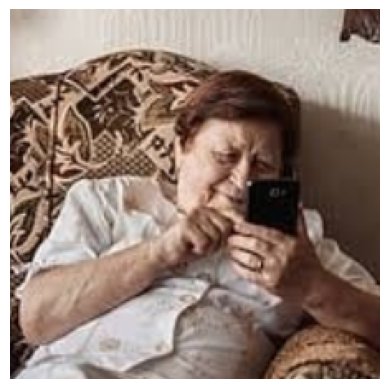

Sample quetion: What task is she completing with headphones?
The practical answer: She listens with headphones.
Câu trả lời dự đoán Pretrained No Attention: ['She listens to music.']
Câu trả lời dự đoán Pretrained With Attention: ['She listens with headphones.']
Câu trả lời dự đoán Trained No Attention: ['She listens with headphones.']
Câu trả lời dự đoán Trained With attention: ['She listens with headphones.']
Press 'Enter' to continue or enter 'stop' to stop: 


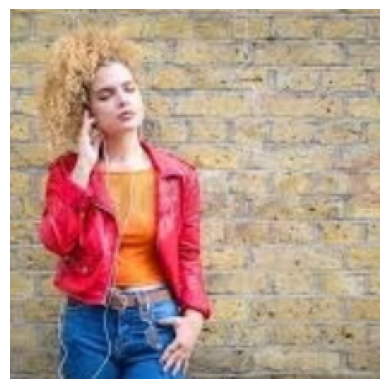

Sample quetion: What feeling does she show?
The practical answer: She shows confidence and fun.
Câu trả lời dự đoán Pretrained No Attention: ['She displays a high level of concentration and calm.']
Câu trả lời dự đoán Pretrained With Attention: ['She looks happy and relaxed.']
Câu trả lời dự đoán Trained No Attention: ['Her mood is intensely happy.']
Câu trả lời dự đoán Trained With attention: ['Her face shows delight and focus.']
Press 'Enter' to continue or enter 'stop' to stop: 


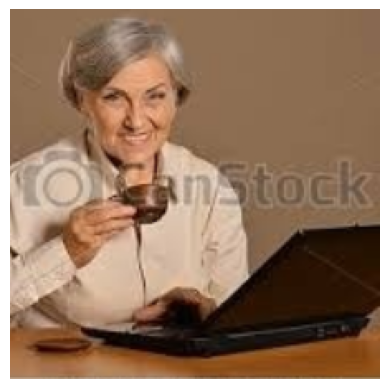

Sample quetion: Does the woman hold a cup while using her laptop?
The practical answer: Yes, the woman holds a cup while using her laptop.
Câu trả lời dự đoán Pretrained No Attention: ['Yes, the woman is sitting while using her phone.']
Câu trả lời dự đoán Pretrained With Attention: ['Yes, the woman is holding a phone to her ear.']
Câu trả lời dự đoán Trained No Attention: ['Yes, the woman is sipping a smoothie with a straw.']
Câu trả lời dự đoán Trained With attention: ['Yes, the woman holds a phone to her ear.']
Press 'Enter' to continue or enter 'stop' to stop: 


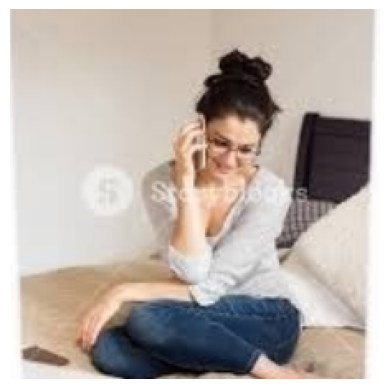

Sample quetion: Can she be seen making a phone call?
The practical answer: Yes, she makes a phone call.
Câu trả lời dự đoán Pretrained No Attention: ['Yes, she makes a phone call.']
Câu trả lời dự đoán Pretrained With Attention: ['Yes, she talks on a phone.']
Câu trả lời dự đoán Trained No Attention: ['Yes, she makes a phone call.']
Câu trả lời dự đoán Trained With attention: ['Yes, she talks on the phone.']
Press 'Enter' to continue or enter 'stop' to stop: 


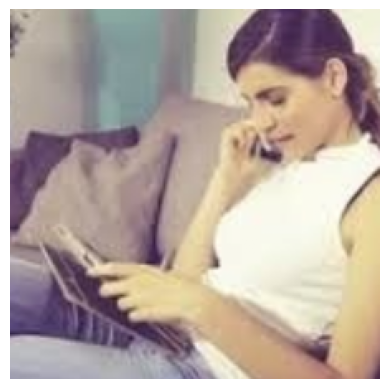

Sample quetion: Is she texting while on a phone call?
The practical answer: Yes, she texts on the phone.
Câu trả lời dự đoán Pretrained No Attention: ['Yes, she talks on a phone while sitting.']
Câu trả lời dự đoán Pretrained With Attention: ['Yes, she talks on a phone.']
Câu trả lời dự đoán Trained No Attention: ['Yes, she talks on a phone.']
Câu trả lời dự đoán Trained With attention: ['Yes, she talks on the phone.']
Press 'Enter' to continue or enter 'stop' to stop: 


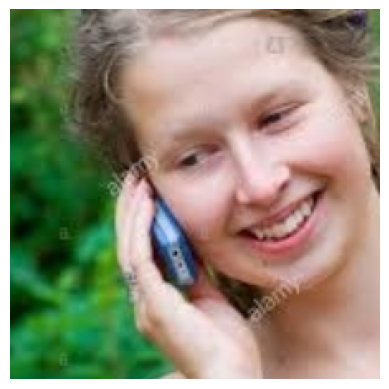

Sample quetion: Is she making a phone call?
The practical answer: Yes, she makes a phone call.
Câu trả lời dự đoán Pretrained No Attention: ['Yes, she makes a phone call.']
Câu trả lời dự đoán Pretrained With Attention: ['Yes, she talks on a phone.']
Câu trả lời dự đoán Trained No Attention: ['Yes, she makes a phone call.']
Câu trả lời dự đoán Trained With attention: ['Yes, she talks on a phone.']
Press 'Enter' to continue or enter 'stop' to stop: 


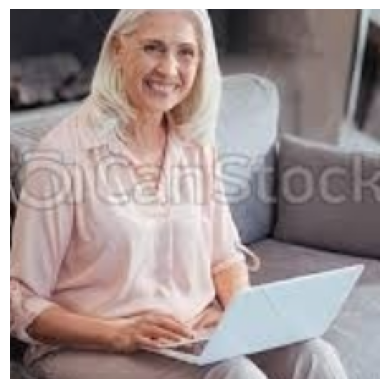

Sample quetion: How is the woman interacting with her laptop?
The practical answer: The woman is using her laptop on a couch.
Câu trả lời dự đoán Pretrained No Attention: ['The woman is working on her laptop while sitting.']
Câu trả lời dự đoán Pretrained With Attention: ['The woman is listening to music with her headphones.']
Câu trả lời dự đoán Trained No Attention: ['The woman is typing on her laptop.']
Câu trả lời dự đoán Trained With attention: ['The woman is listening to music with her headphones.']
Press 'Enter' to continue or enter 'stop' to stop: 


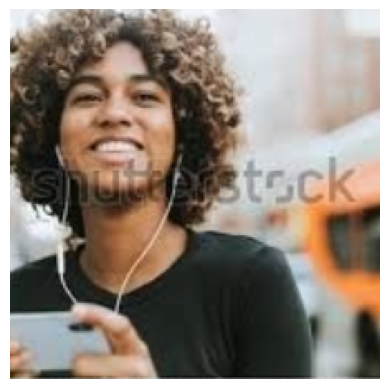

Sample quetion: How does the woman feel while listening outdoors?
The practical answer: She feels joyful and energized.
Câu trả lời dự đoán Pretrained No Attention: ['She feels calm and content.']
Câu trả lời dự đoán Pretrained With Attention: ['She feels relaxed and content.']
Câu trả lời dự đoán Trained No Attention: ['She feels happy and relaxed.']
Câu trả lời dự đoán Trained With attention: ['She feels calm and content.']
Press 'Enter' to continue or enter 'stop' to stop: stop
stopped.


In [24]:

for idx in range(len(test_dataset)):
    # Lấy mẫu từ val_dataset
    sample_image, sample_question, sample_answer = test_dataset[idx]

    # In hình ảnh
    sample_image_display = sample_image.clone()
    sample_image_display[0] = sample_image_display[0] * 0.229 + 0.485  # Đảo ngược chuẩn hóa cho kênh R
    sample_image_display[1] = sample_image_display[1] * 0.224 + 0.456  # Đảo ngược chuẩn hóa cho kênh G
    sample_image_display[2] = sample_image_display[2] * 0.225 + 0.406  # Đảo ngược chuẩn hóa cho kênh B
    sample_image_display = sample_image_display.clamp(0, 1)
    sample_image_display = sample_image_display.permute(1, 2, 0).numpy()
    plt.imshow(sample_image_display)
    plt.axis('off')
    plt.show()

    # In câu hỏi mẫu
    question_text = ' '.join([inv_vocab[idx.item()] for idx in sample_question if idx.item() != vocab['<pad>']])
    print(f"Sample quetion: {question_text}")

    # In câu trả lời thực tế
    answer_text = ' '.join([inv_vocab[idx.item()] for idx in sample_answer if idx.item() != vocab['<pad>'] and idx.item() != vocab['<start>'] and idx.item() != vocab['<end>']])
    print(f"The practical answer: {answer_text}")

    # Chuẩn bị dữ liệu một lần trước khi dự đoán
    sample_image = sample_image.unsqueeze(0).to(device)  # Di chuyển ra ngoài vòng lặp
    sample_question = sample_question.unsqueeze(0).to(device)  # Di chuyển ra ngoài vòng lặp

    # Dự đoán và in kết quả cho 4 mô hình
    model_list = [pretrained_no_attention, pretrained_with_attention,trained_no_attention, trained_with_attention]
    model_names = ['Pretrained No Attention', 'Pretrained With Attention','Trained No Attention', 'Trained With attention']
    for model, name in zip(model_list, model_names):
        model.eval()
        with torch.no_grad():
            predicted_answer = model(sample_image, sample_question)  # Không cần unsqueeze nữa
        print(f"Câu trả lời dự đoán {name}: {predicted_answer}")


    # Kiểm tra xem người dùng có muốn dừng không
    user_input = input("Press 'Enter' to continue or enter 'stop' to stop: ")
    if user_input.lower() == 'stop':
        print("stopped.")
        break
